# Image classification

The first stage of the IFT processing is to generate a 4-class image classification: land, water, ice, and cloud. 


```
classification(false_color_image, land mask)
    clouds = cloud_mask(false_color_image) |> apply_landmask
    ice = preliminary_ice_mask(red band |> apply_landmask)
    water = not land, not ice, not cloud
    return masks
end
```
    
Methods to work out:
1. Optimization code, varying tau_i. Then, checking the false-negative regions -- compute the contrast within them to set the minimum contrast (and potentially other metrics). Q: which loss function should we use? error weighted by the 3 surface types?
2. Computation of the accuracy statistics for the initial analysis. Consider removing the histogram figures, or re-doing them with the easier-to-follow labeling scheme.
3. Re-do the example figure for classification so there is a single figure, make it horizontal, and have two cases: one with the MODIS cloud error, and one with good agreement between the masks.
4. Re-write the classification section for compactness.
5. Produce gridded sea ice concentration maps, so we can avoid some of the cloud-as-ice errors.
6. Potential end-of-paper result: maps of the surface-type frequency for the full images using the random sample dates? That would be 21 cases for each region.


In [2]:
using Pkg
Pkg.activate("../scripts/calval")
# Pkg.update(; name="IceFloeTracker", rev="main")
using CairoMakie
using CSVFiles
using DataFrames
using Dates
using IceFloeTracker
using Images
using Random
using StatsBase


  Activating project at `~/Documents/research/manuscripts/calval_tgrs/scripts/calval`


In [3]:
# load test images -- currently these don't work correctly, some issue with missing data

function validated_binary_water(case::Case)
    info(case).water_sample == 0 && return nothing
    (; case_number, region, date, satellite) = IceFloeTracker.Data._filename_parts(case)
    file = "data/validation_dataset/binary_water_samples/$(case_number)-$(region)-$(date)-$(satellite)-binary_water_samples.png"
    img = file |> case.loader |> load |> binarize_mask .|> Gray
    return img
end

function validated_binary_cloud(case::Case)
    info(case).ice_sample == 0 && return nothing
    (; case_number, region, date, satellite) = IceFloeTracker.Data._filename_parts(case)
    file = "data/validation_dataset/binary_ice_samples/$(case_number)-$(region)-$(date)-$(satellite)-binary_ice_samples.png"
    img = file |> case.loader |> load |> binarize_mask .|> Gray
    return img
end

function validated_binary_ice(case::Case)
    info(case).cloud_sample == 0 && return nothing
    (; case_number, region, date, satellite) = IceFloeTracker.Data._filename_parts(case)
    file = "data/validation_dataset/binary_cloud_samples/$(case_number)-$(region)-$(date)-$(satellite)-binary_cloud_samples.png"
    img = file |> case.loader |> load |> binarize_mask .|> Gray
    return img
end

validated_binary_ice (generic function with 1 method)

In [260]:
# Initialize dataset
dataset = Watkins2026Dataset(ref="main")

# Add a columns to indicate whether samples have been generated yet
water_sample_files = readdir("../../ice_floe_validation_dataset/data/validation_dataset/binary_water_samples/")
water_sample_files = filter(r -> r != ".DS_Store", water_sample_files)
water_sample_cases = parse.(Int64, first.(split.(water_sample_files, "-")))
dataset.info[:, :water_sample] = (x -> x ∈ water_sample_cases).(dataset.info.case_number)

ice_sample_files = readdir("../../ice_floe_validation_dataset/data/validation_dataset/binary_ice_samples/")
ice_sample_files = filter(r -> r != ".DS_Store", ice_sample_files)
ice_sample_cases = parse.(Int64, first.(split.(ice_sample_files, "-")))
dataset.info[:, :ice_sample] = (x -> x ∈ ice_sample_cases).(dataset.info.case_number)

cloud_sample_files = readdir("../../ice_floe_validation_dataset/data/validation_dataset/binary_cloud_samples/")
cloud_sample_files = filter(r -> r != ".DS_Store", cloud_sample_files)
cloud_sample_cases = parse.(Int64, first.(split.(cloud_sample_files, "-")))
dataset.info[:, :cloud_sample] = (x -> x ∈ cloud_sample_cases).(dataset.info.case_number);

In [267]:
dataset.info[dataset.info.case_number .== 105, :]

Row,,case_number,region,satellite,start_date,pass_time,center_lon,center_lat,center_x,center_y,sea_ice_fraction,mean_sea_ice_concentration,visible_sea_ice,visible_landfast_ice,visible_floes,visible_water,number_floes,mean_floe_size,total_floe_area,minimum_floe_size,maximum_floe_size,cloud_fraction_manual,cloud_category_manual,artifacts,floe_obscuration,landfast_obscuration,water_sample,ice_sample,cloud_sample
,Int64,Int64,String,String,Date,DateTime,Float64,Float64,Int64,Int64,Float64,Float64,String,String,String,String,Int64,Float64?,Float64?,Int64,Int64,Float64,String,String,String,String,Bool,Bool,Bool
1,208,105,east_siberian_sea,aqua,2018-08-09,2018-08-09T23:40:32,176.143,75.5178,-1037500,1187500,1.0,0.729,yes,no,yes,yes,5,229.6,1148.0,118,380,0.1,thin,no,none,,false,true,false
2,209,105,east_siberian_sea,terra,2018-08-09,2018-08-09T00:15:45,176.143,75.5178,-1037500,1187500,1.0,0.729,yes,no,yes,yes,0,missing,missing,0,0,0.4,thin,yes,moderate,,false,true,false


We'll need to do to things: first, set up a function that classifies pixels in the image into 4 categories; second, a function that loads the labeled images for evaluation. Critically, the labeled images do not fully partition the image, so we don't penalize background.

In [268]:
"""

Produces a segmented image with up to 4 categories: land, water, ice, and cloud.

"""
function ift_classification(false_color_image, land_mask;
        tau_1=0.3,
        tau_2=0.15,
        tau_7=0.34,
        label_map=Dict("land"=>0, "water"=>1, "ice"=>2, "cloud"=>3)
    )
    
    cloud_mask_algorithm=Watkins2026CloudMask(
        band_7_threshold = tau_7,
        band_2_threshold = tau_2,
        opening_strel = strel_disk(3),
        dilation_strel = strel_disk(2),
        min_hole_size = 300,
        max_fill_size = 1e4,
        min_contrast = 0.2,
        ) 

    ice_mask_algorithm=IceDetectionBrightnessMidpoint(minimum_reflectance=tau_1)
    
    coastal_buffer = create_coastal_buffer_mask(land_mask .> 0, strel_disk(25))
    fc_masked = apply_landmask(false_color_image, coastal_buffer)
    clouds = cloud_mask_algorithm(fc_masked) .> 0
    band_1_masked = Gray.(blue.(apply_landmask(fc_masked, clouds)))
    ice = ice_mask_algorithm(band_1_masked) .> 0
    
    classified_image = ones(Int64, size(false_color_image)) .* label_map["water"]
    classified_image[coastal_buffer] .= label_map["land"]
    classified_image[ice] .= label_map["ice"]
    classified_image[clouds] .= label_map["cloud"]
    
    return SegmentedImage(false_color_image, classified_image)
end

ift_classification

In [51]:
case = first(filter(c -> (c.case_number == 11 && c.satellite == "aqua"), dataset))

Case(GitHubLoader("https://github.com/danielmwatkins/ice-floe-validation-dataset", "v0.2", "/tmp/Watkins2026"), DataFrameRow
 Row │        case_number  region      satellite  start_date  pass_time        ⋯
     │ Int64  Int64        String      String     Date        DateTime         ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │    20           11  baffin_bay  aqua       2011-07-02  2011-07-02T16:31 ⋯
                                                              24 columns omitted)

In [52]:
fc_img = modis_falsecolor(case)
lm_img = modis_landmask(case);

In [53]:
segments = ift_classification(fc_img, lm_img)

Segmented Image with:
  labels map: 400×400 Matrix{Int64}
  number of labels: 2

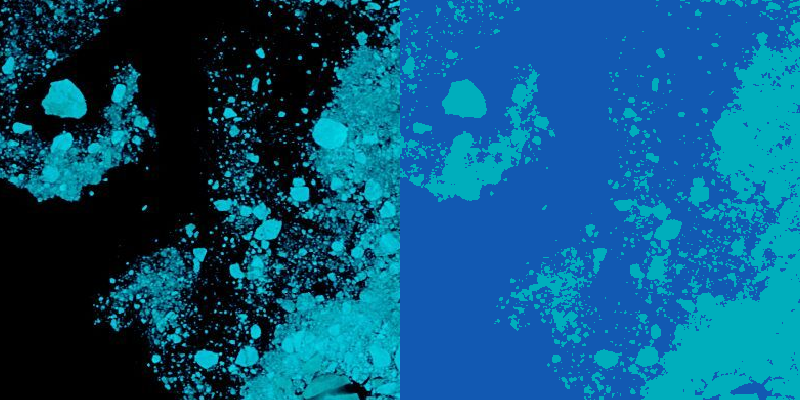

In [54]:
mosaicview(fc_img, view_seg_random(segments), nrow=1)

In [269]:
#### Use the previously defined test/train split ####
using CSV
prior_data = DataFrame(CSV.File("../data/train_test_split.csv")) # want to use CSVFiles but need a few extra steps
dataset.info[:, :training_sample] = prior_data[:, :training_sample]
dataset.info[:, :testing_sample] = prior_data[:, :testing_sample]
train_cases = filter(c -> c.training_sample, dataset) 
test_cases = filter(c -> c.testing_sample, dataset);

# Add column with cloud fraction path
cloudfrac_loc = "../data/cloudfraction_numeric/"
transform!(train_cases.info, [:case_number, :region, :satellite, :start_date] => ByRow((cn, r, s, d) ->
    join([lpad(cn, 3, "0"), r, Dates.format(d, "yyyymmdd"), s, "cloudfraction.csv"], "-")) => :cloudfrac_file)

train_tc_imgs = modis_truecolor.(train_cases)
train_fc_imgs = modis_falsecolor.(train_cases)
train_binary_floes = validated_binary_floes.(train_cases)
train_land_masks = modis_landmask.(train_cases) .|> r -> r .> 0; # Load land masks and convert to binary
train_landfast_ice_masks = validated_binary_landfast.(train_cases);

# Add column with cloud fraction path
cloudfrac_loc = "../data/cloudfraction_numeric/"
transform!(train_cases.info, [:case_number, :region, :satellite, :start_date] => ByRow((cn, r, s, d) ->
    join([lpad(cn, 3, "0"), r, Dates.format(d, "yyyymmdd"), s, "cloudfraction.csv"], "-")) => :cloudfrac_file)

# Load numeric cloud fraction data
train_modis_cloudfrac = load.(joinpath.(cloudfrac_loc, train_cases.info[:, :cloudfrac_file])) .|> 
                            DataFrame .|> r -> Array(r[:, 2:end]);

function masked_mean(data, mask)
    d = vec(data)
    m = vec(mask) .> 0
    return mean(d[.!m])
end

function fill_missing!(cases; template=Gray.(zeros(Bool, (400, 400))))
    for (idx, img) in enumerate(cases)
        if isnothing(img)
            cases[idx] = template
        end
    end
end

fill_missing!(train_binary_floes)
fill_missing!(train_landfast_ice_masks)


# Generate binary MODIS mask with 75% threshold
modis_cloud_masks = [m .> 75 for (m, f) in zip(train_modis_cloudfrac, train_fc_imgs)]

# compute MODIS estimated cloud fraction for all pixels
train_cases.info[:, :lookup_index] .= 1:length(train_cases) # This gives us the index for the data loaders
train_cases.info[:, "cloud_fraction_modis"] = round.(mean.(train_modis_cloudfrac) ./ 100, digits=2);
train_cases.info[:, "cloud_fraction_modis_ocean"] = round.(masked_mean.(train_modis_cloudfrac, train_land_masks)./ 100, digits=2);

In [85]:
# Still some challenges loading the training ice/water/cloud masks

# train_ice_masks = validated_binary_ice.(train_cases);
# train_cloud_masks = validated_binary_cloud.(train_cases);
# train_water_masks = validated_binary_water.(train_cases);
# fill_missing!(train_ice_masks)
# fill_missing!(train_water_masks)


In [123]:
train_buffers = create_coastal_buffer_mask.(train_land_masks, [strel_disk(25)]);

In [270]:
# variant of this should work, just need an if-then for filling in blank if the file doesn't exist yet
data_loc = "../../ice_floe_validation_dataset/data/validation_dataset/"
file_names = [
     join([lpad(cn, 3, "0"), r, Dates.format(d, "yyyymmdd"), s, "binary_water_samples.png"], "-")
    for (cn, r, s, d) in zip(
            train_cases.info.case_number,
            train_cases.info.region,
            train_cases.info.satellite,
            train_cases.info.start_date
            )
    ]
train_binary_water_samples = [sample_present==1 ? load.(joinpath.(data_loc, "binary_water_samples", f)) .|> r -> Gray.(r) .> 0 : zeros((400,400))
    for (f, sample_present) in zip(file_names, train_cases.info.water_sample)
        ];
train_binary_cloud_samples = [sample_present==1 ? load.(joinpath.(data_loc, "binary_cloud_samples", f)) .|> r -> Gray.(r) .> 0 : zeros((400,400))
    for (f, sample_present) in zip(replace.(file_names, "water"=>"cloud"), train_cases.info.cloud_sample)
        ];
train_binary_ice_samples = [sample_present==1 ? load.(joinpath.(data_loc, "binary_ice_samples", f)) .|> r -> Gray.(r) .> 0 : zeros((400,400))
    for (f, sample_present) in zip(replace.(file_names, "water"=>"ice"), train_cases.info.ice_sample)
        ];

In [271]:
# corrections
manual_low = train_cases.info.cloud_fraction_manual .<= 0.1
modis_high = train_cases.info.cloud_fraction_modis .> 0.3
train_cases.info[manual_low .&& modis_high,  [:cloud_fraction_manual, :cloud_fraction_modis, :lookup_index, :case_number]]

Row,cloud_fraction_manual,cloud_fraction_modis,lookup_index,case_number
,Float64,Float64,Int64,Int64
1,0.0,0.5,11,11
2,0.1,0.88,107,181


In [272]:
# computing the error in the classification function
# background / no label = 0 (not evaluating land classification!)
# true water = 1 -> water samples masks
# true ice = 2 -> ice samples masks + ice floes for cases with modis cloud < 25%
# true cloud = 3 -> modis cloud mask > 75 & not land or cloud sample

# To compute the loss, we want to find the fraction of non-background for each category which 
# the segmented and true images don't match. We need to do this per category

labeled_ground_truth = [zeros(Int64, size(train_land_masks[1])) for i in 1:length(train_land_masks)];
for idx in 1:length(labeled_ground_truth)
    cb = train_binary_cloud_samples[idx]
    ib = train_binary_ice_samples[idx]
    cm = apply_landmask(train_modis_cloudfrac[idx], train_buffers[idx])
    fl = train_binary_floes[idx]
    w = train_binary_water_samples[idx]
    labeled_ground_truth[idx][w .> 0] .= 1
    # Non-cloudy ice floes
    labeled_ground_truth[idx][(fl .> 0) .&& (cm .< 25)] .= 2
    labeled_ground_truth[idx][ib .> 0] .= 2
    if idx ∉ [11, 107] # check lookup numbers in cell above
        labeled_ground_truth[idx][cm .> 95] .= 3 # Note -- some errors in MODIS mask! e.g. case 11.
    end
    labeled_ground_truth[idx][cb .> 0] .= 3
end



In [253]:
segments = ift_classification.(train_fc_imgs, train_land_masks);

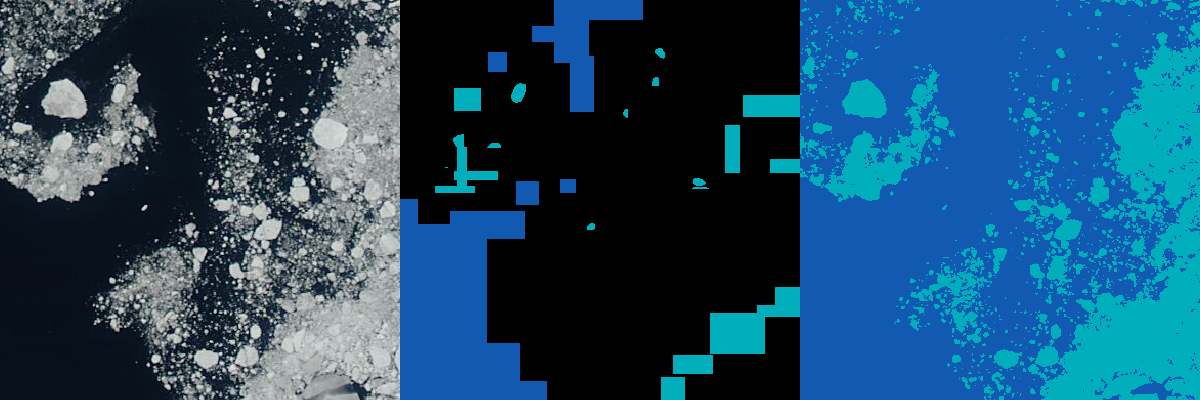

In [254]:
# Case 11: Where we know the MODIS mask is off
idx = 11
mosaicview(train_tc_imgs[idx],
        view_seg_random(SegmentedImage(train_fc_imgs[idx], labeled_ground_truth[idx])),
        view_seg_random(segments[idx]), nrow=1)


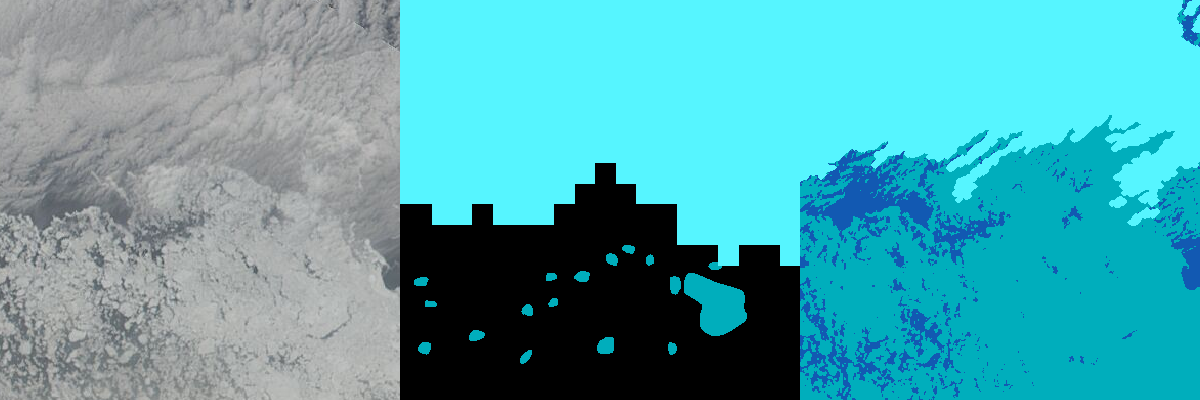

In [273]:
idx = 48*2
mosaicview(train_tc_imgs[idx],
        view_seg_random(SegmentedImage(train_fc_imgs[idx], labeled_ground_truth[idx])),
        view_seg_random(segments[idx]), nrow=1)


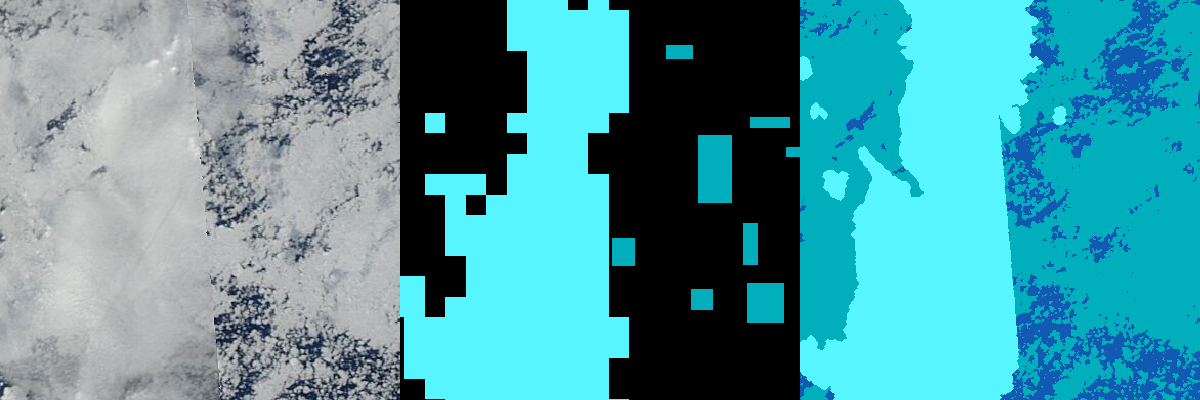

In [274]:
idx = 63
mosaicview(train_tc_imgs[idx],
        view_seg_random(SegmentedImage(train_fc_imgs[idx], labeled_ground_truth[idx])),
        view_seg_random(segments[idx]), nrow=1)

Next step: generate confusion matrix, by class. Check built-in methods for Flux.jl.

- One Hot Arrays -- that's where we transform categorical data into multiple binary columns
- 

In [275]:
labeled_predicted = labels_map.(segments);

In [276]:
"""

Generate a confusion matrix with rows being true values and cols being predicted.
Only computes values where the ground truth GT is not equal to 0.
"""
function confusion_matrix(GT, P; classes=1:3, normalize=false)
    n = length(classes)
    if normalize
        CM = zeros(Float64, (n, n))    
    else
        CM = zeros(Int64, (n, n))
    end
    for (row, ci) in enumerate(classes)
        for (col, cj) in enumerate(classes)
            CM[row, col] = sum((GT .== ci .&& GT .!= 0) .&& (P .== cj .&&  GT .!= 0))
            if normalize
                n = sum(GT .== ci .&& GT .!= 0)
                if n > 0
                    CM[row, col] /= n
                end
            end
        end
    end
    return CM
end

confusion_matrix

In [277]:
# label_map=Dict("land"=>0, "water"=>1, "ice"=>2, "cloud"=>3)
idx = 14
cm = confusion_matrix(labeled_ground_truth[idx], labeled_predicted[idx]; normalize=false)
function prettyprint_cm(cm)
    println("predicted: water      ice    cloud")
    for (ii, label) in enumerate(["water", "ice", "cloud"])
        println(rpad(label, 8, " "), join([lpad(x, 8, " ") for x in cm[ii, :]], " "))
    end
end
prettyprint_cm(cm)

predicted: water      ice    cloud
water        417        0        0
ice            5     1069      164
cloud       6837     3688     6496


Interpretting the confusion matrix. Summing across the rows gives the total of true values in each category, while summing down the columns gives the number of predictions in each. Anything off-diagonal is a miss-prediction.

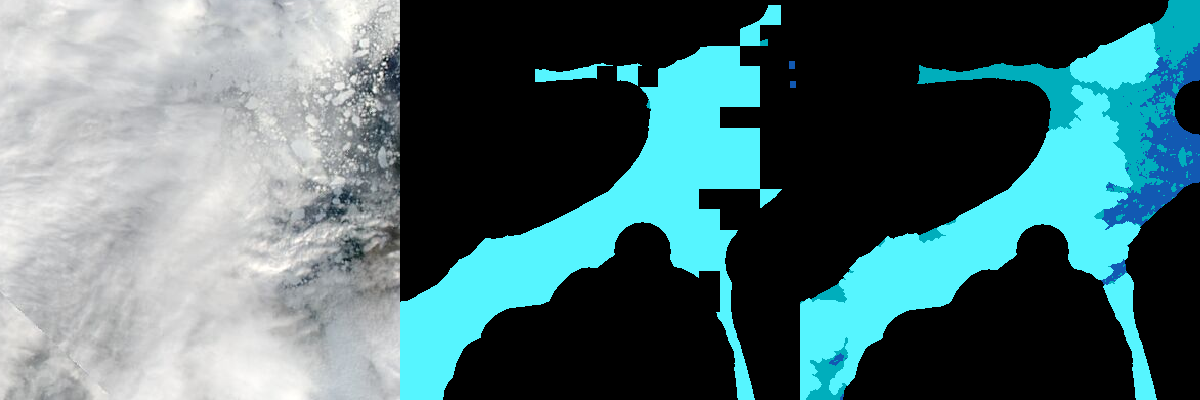

In [285]:
idx = 13
mosaicview(train_tc_imgs[idx],
        view_seg_random(SegmentedImage(train_fc_imgs[idx], labeled_ground_truth[idx])),
        view_seg_random(segments[idx]), nrow=1)


In [279]:
cms = confusion_matrix.(labeled_ground_truth, labeled_predicted; normalize=false);


In [280]:
overall = sum(cms)
prettyprint_cm(overall)

predicted: water      ice    cloud
water     218382        0        3
ice         2452   463594     2788
cloud     665139  1660133  8892727


## Normalized confusion matrix

In [282]:
# true number per category = sum down columns
overall ./ sum(overall; dims=2)

3×3 Matrix{Float64}:
 0.999986   0.0       1.37372e-5
 0.00523    0.988823  0.00594667
 0.0592921  0.147988  0.79272

In [288]:
using LinearAlgebra
tr(overall) ./ sum(sum(overall))

0.804244239794685

## Calibration

Running the classification and accuracy test for one parameter takes 14 seconds, so doing a simple parameter sweep won't take very long.

In [298]:
results = DataFrame(
            tau_1=Float64[],
            tau_2=Float64[],
            tau_7=Float64[],
            water=Float64[],
            ice=Float64[],
            cloud=Float64[],
            overall=Float64[]
    )
# Save results as 
@time begin
    tau_2 = 0.15
    tau_7 = 0.34
    for tau_1 in 0.2:0.05:0.5
            
        parameters = (
            tau_1=tau_1,
            tau_2=tau_2,
            tau_7=tau_7,
        )
        segments = ift_classification.(train_fc_imgs, train_land_masks; parameters...);
        labeled_predicted = labels_map.(segments);
        conf = sum(confusion_matrix.(labeled_ground_truth, labeled_predicted; normalize=false));
        overall_accuracy = tr(conf) / sum(sum(conf))
        category_accuracy = diag(conf ./ sum(conf; dims=2))
        push!(results, [tau_1, tau_2, tau_7, category_accuracy..., overall_accuracy])
    end
end

 98.740260 seconds (766.93 k allocations: 13.850 GiB, 2.41% gc time, 0.05% compilation time)


In [299]:
results

Row,tau_1,tau_2,tau_7,water,ice,cloud,overall
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.2,0.15,0.34,0.999986,0.990323,0.79272,0.804303
2,0.25,0.15,0.34,0.999986,0.989647,0.79272,0.804277
3,0.3,0.15,0.34,0.999986,0.988823,0.79272,0.804244
4,0.35,0.15,0.34,0.999986,0.9873,0.79272,0.804184
5,0.4,0.15,0.34,0.999986,0.98562,0.79272,0.804118
6,0.45,0.15,0.34,0.999986,0.982674,0.79272,0.804002
7,0.5,0.15,0.34,0.999986,0.978186,0.79272,0.803825


In [300]:
# Append to results
@time begin
    tau_1 = 0.2
    tau_7 = 0.34
    for tau_2 in 0.1:0.05:0.6
        parameters = (
            tau_1=tau_1,
            tau_2=tau_2,
            tau_7=tau_7,
        )
        segments = ift_classification.(train_fc_imgs, train_land_masks; parameters...);
        labeled_predicted = labels_map.(segments);
        conf = sum(confusion_matrix.(labeled_ground_truth, labeled_predicted; normalize=false));
        overall_accuracy = tr(conf) / sum(sum(conf))
        category_accuracy = diag(conf ./ sum(conf; dims=2))
        push!(results, [tau_1, tau_2, tau_7, category_accuracy..., overall_accuracy])
    end
end

153.687020 seconds (981.49 k allocations: 21.737 GiB, 1.54% gc time)


In [334]:
results

Row,tau_1,tau_2,tau_7,water,ice,cloud,overall
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.2,0.15,0.34,0.999986,0.990323,0.79272,0.804303
2,0.25,0.15,0.34,0.999986,0.989647,0.79272,0.804277
3,0.3,0.15,0.34,0.999986,0.988823,0.79272,0.804244
4,0.35,0.15,0.34,0.999986,0.9873,0.79272,0.804184
5,0.4,0.15,0.34,0.999986,0.98562,0.79272,0.804118
6,0.45,0.15,0.34,0.999986,0.982674,0.79272,0.804002
7,0.5,0.15,0.34,0.999986,0.978186,0.79272,0.803825
8,0.2,0.1,0.34,0.999986,0.990323,0.792726,0.80431
9,0.2,0.15,0.34,0.999986,0.990323,0.79272,0.804303


In [322]:
# Append to results
@time begin
    tau_1 = 0.2
    tau_2 = 0.4
    for tau_7 in 0.1:0.05:0.6
        parameters = (
            tau_1=tau_1,
            tau_2=tau_2,
            tau_7=tau_7,
        )
        segments = ift_classification.(train_fc_imgs, train_land_masks; parameters...);
        labeled_predicted = labels_map.(segments);
        conf = sum(confusion_matrix.(labeled_ground_truth, labeled_predicted; normalize=false));
        overall_accuracy = tr(conf) / sum(sum(conf))
        category_accuracy = diag(conf ./ sum(conf; dims=2))
        push!(results, [tau_1, tau_2, tau_7, category_accuracy..., overall_accuracy])
    end
end


154.852280 seconds (10.13 M allocations: 21.969 GiB, 1.60% gc time, 1.00% compilation time: 100% of which was recompilation)


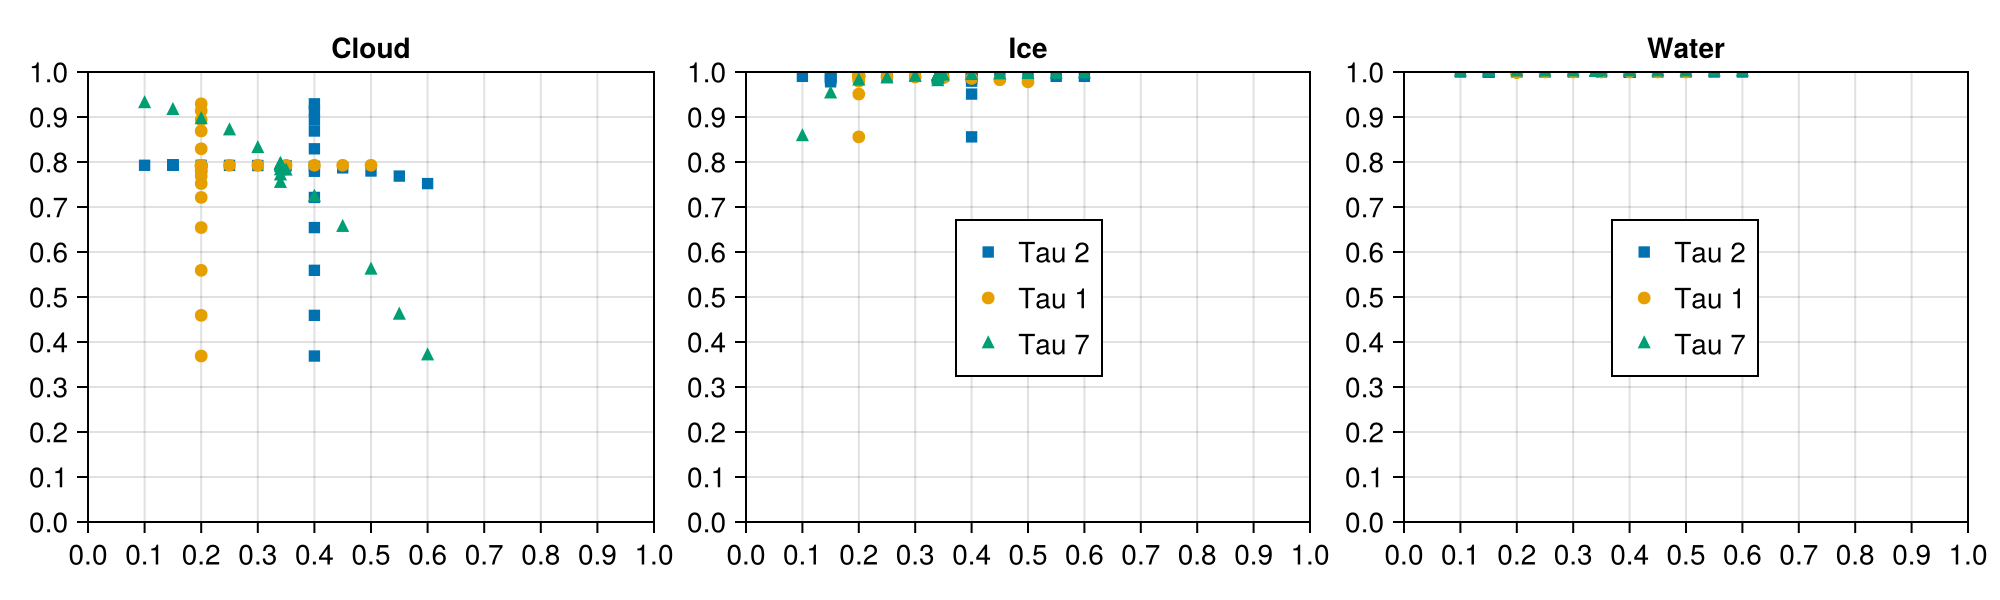

In [333]:
f = CairoMakie.Figure(size=(1000, 300))
ax1 = CairoMakie.Axis(f[1, 1], limits=(0, 1, 0, 1), title="Cloud", yticks=0:0.1:1, xticks=0:0.1:1)
scatter!(ax1, results.tau_2, results.cloud, label="Tau 2", marker=:rect)
scatter!(ax1, results.tau_1, results.cloud, label="Tau 1", marker=:circle)
scatter!(ax1, results.tau_7, results.cloud, label="Tau 7", marker=:utriangle)

ax2 = CairoMakie.Axis(f[1, 2], limits=(0, 1, 0, 1), xticks=0:0.1:1, title="Ice", yticks=0:0.1:1)
scatter!(ax2, results.tau_2, results.ice, label="Tau 2", marker=:rect)
scatter!(ax2, results.tau_1, results.ice, label="Tau 1", marker=:circle)
scatter!(ax2, results.tau_7, results.ice, label="Tau 7", marker=:utriangle)

ax3 = CairoMakie.Axis(f[1, 3], limits=(0, 1, 0, 1), xticks=0:0.1:1, title="Water", yticks=0:0.1:1)
scatter!(ax3, results.tau_2, results.water, label="Tau 2", marker=:rect)
scatter!(ax3, results.tau_1, results.water, label="Tau 1", marker=:circle)
scatter!(ax3, results.tau_7, results.water, label="Tau 7", marker=:utriangle)

# Legend(f[1, 1], ax1, tellheight=false, tellwidth=false, position=:right_bottom)
Legend(f[1, 2], ax2, tellheight=false, tellwidth=false)
Legend(f[1, 3], ax3, tellheight=false, tellwidth=false)
f

The figure shows change in accuracy as the color-coded parameter is changed across a range. 

In [297]:
# Append to results
@time begin
    tau_1 = 0.2
    tau_2 = 0.2
    for tau_7 in 0.1:0.05:0.6
        parameters = (
            tau_1=tau_1,
            tau_2=tau_2,
            tau_7=tau_7,
        )
        segments = ift_classification.(train_fc_imgs, train_land_masks; parameters...);
        labeled_predicted = labels_map.(segments);
        conf = sum(confusion_matrix.(labeled_ground_truth, labeled_predicted; normalize=false));
        overall_accuracy = tr(conf) / sum(sum(conf))
        category_accuracy = diag(conf ./ sum(conf; dims=2))
        push!(results, [tau_1, tau_2, tau_7, category_accuracy..., overall_accuracy])
    end
end

5-element Vector{Float64}:
 0.2
 0.25
 0.3
 0.35
 0.4

labels_map (generic function with 1 method)

In [350]:
# Dict("land"=>0, "water"=>1, "ice"=>2, "cloud"=>3)

# Construct histograms of band-wise colors
modis_threshold = 75
b2_clouds = []
b7_clouds = []
b1_clouds = []
b2_non_clouds = []
b1_non_clouds = []
b7_non_clouds = []
for idx in train_cases.info.lookup_index
    clouds = vec(labeled_ground_truth[idx] .== 3) 
    water = vec(labeled_ground_truth[idx] .== 1)
    ice = vec(labeled_ground_truth[idx] .== 2)
    b2 = green.(train_fc_imgs[idx])
    b7 = red.(train_fc_imgs[idx])
    b1 = vec(blue.(train_fc_imgs[idx]))

    push!(b2_clouds, Float64.(b2[clouds]))
    push!(b7_clouds, Float64.(b7[clouds]))
    push!(b1_clouds, Float64.(b1[clouds]))

    selection = water .|| ice
    push!(b2_non_clouds, Float64.(b2[selection]))
    push!(b7_non_clouds, Float64.(b7[selection]))
    push!(b1_non_clouds, Float64.(b1[selection]))
    
end
b1_clouds = vcat(b1_clouds...)
b2_clouds = vcat(b2_clouds...)
b7_clouds = vcat(b7_clouds...)
b2_non_clouds = vcat(b2_non_clouds...)
b7_non_clouds = vcat(b7_non_clouds...)
b1_non_clouds = vcat(b1_non_clouds...);

B2 quantiles[0.2784313725490196, 0.6745098039215687, 0.803921568627451, 0.8745098039215686, 0.9450980392156862]
B7 quantiles[0.03529411764705882, 0.3254901960784314, 0.5058823529411764, 0.6392156862745098, 0.7098039215686275]


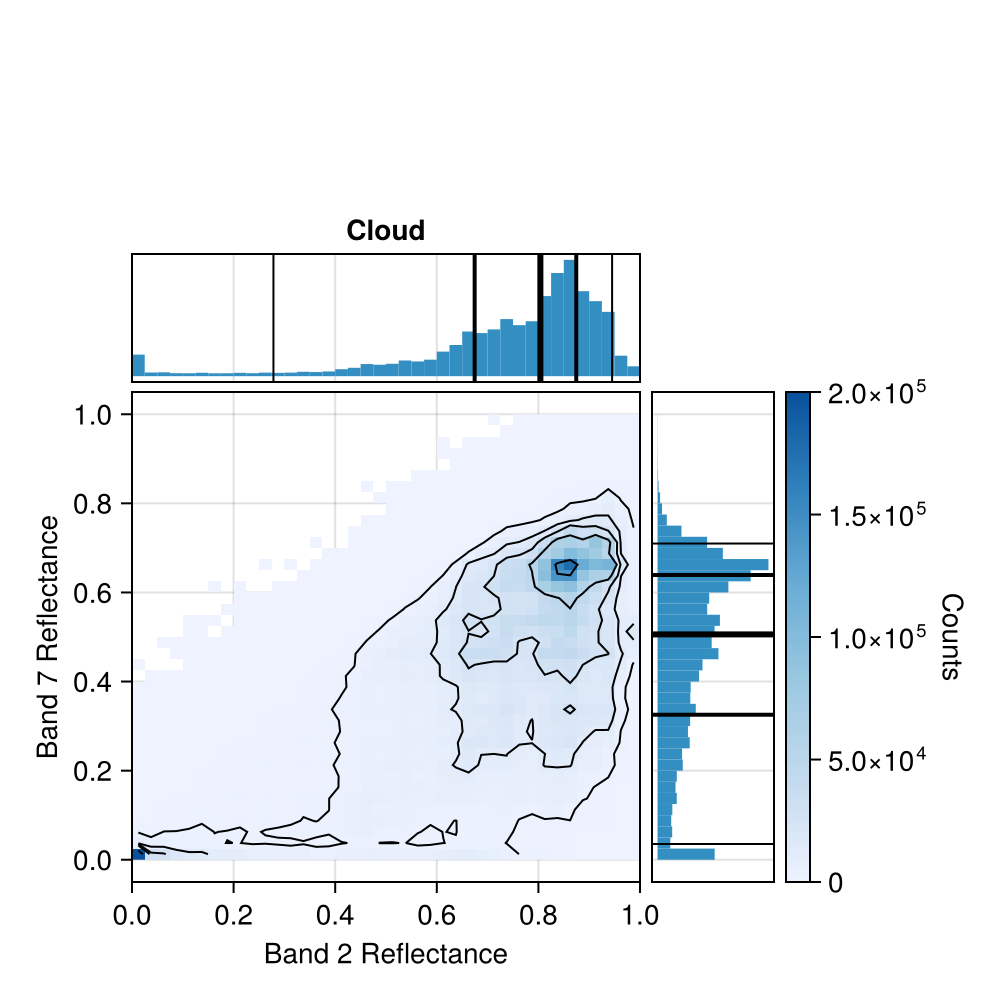

In [340]:
using FHist
using Interpolations

fig = Figure(size=(500,500))

bins = 0:0.025:1
h2 = Hist1D(b2_clouds; binedges=bins);
h7 = Hist1D(b7_clouds, binedges=bins);
h2h7 = Hist2D((b2_clouds, b7_clouds), binedges=(bins, bins));

H = h2h7.bincounts
s = integral(h2h7)
Hd = H ./ s
F = range(0, maximum(Hd), 50)
L = round.([1-sum(Hd[Hd .> f]) for f in F], digits=3)

df = DataFrame(F=F, L=L)
df = df[.!nonunique(df, "L"), :];

pct = [0.05, 0.25, 0.5, 0.75, 0.95]
f = linear_interpolation(df[:, :L], df[:, :F])
levels = f.(pct) * s;

ax1, _ = hist(fig[1, 1],h2; axis=(xticks=0:0.2:1, yticks=[], title="Cloud"))
ax3, _h2h7 = plot(fig[2, 1], h2h7; colormap=:Blues_6, colorrange=(0, 2e5),
    axis=(ylabel="Band 7 Reflectance", xlabel="Band 2 Reflectance", 
        xticks=0:0.2:1, yticks=0:0.2:1))
contour!(ax3, h2h7; 
    levels=levels, labels=false, color=:black)
Colorbar(fig[2, 3], _h2h7; label="Counts", labelrotation=-pi/2)
ax2, _ = hist(fig[2, 2], h7; direction=:x, axis=(yticks=0:0.2:1, xticks=[]))
ax2.aspect = 0.25
ax1.aspect = 4
b2_qs = quantile(b2_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
println("B2 quantiles", b2_qs)
vlines!(ax1, b2_qs, color=:black, linewidth=1)
vlines!(ax1, b2_qs[[2, 4]], color=:black, linewidth=2)
vlines!(ax1, b2_qs[[3]], color=:black, linewidth=3)


b7_qs = quantile(b7_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
println("B7 quantiles", b7_qs)
hlines!(ax2, b7_qs, color=:black, linewidth=1)
hlines!(ax2, b7_qs[[2, 4]], color=:black, linewidth=2)
hlines!(ax2, b7_qs[[3]], color=:black, linewidth=3)


linkyaxes!(ax3, ax2)
linkxaxes!(ax3, ax1)
hidedecorations!(ax1, grid = false)
hidedecorations!(ax2, grid = false)
colgap!(fig.layout, -90)
rowgap!(fig.layout,  -85)
# statbox!(fig, h2h7; position=(2,4))
# save("../figures/fig_04a_cloud_histogram.pdf", fig)
# save("../figures/fig_04a_cloud_histogram.pdf", fig, px_per_unit=1)
fig

B2 quantiles[0.2784313725490196, 0.6745098039215687, 0.803921568627451, 0.8745098039215686, 0.9450980392156862]


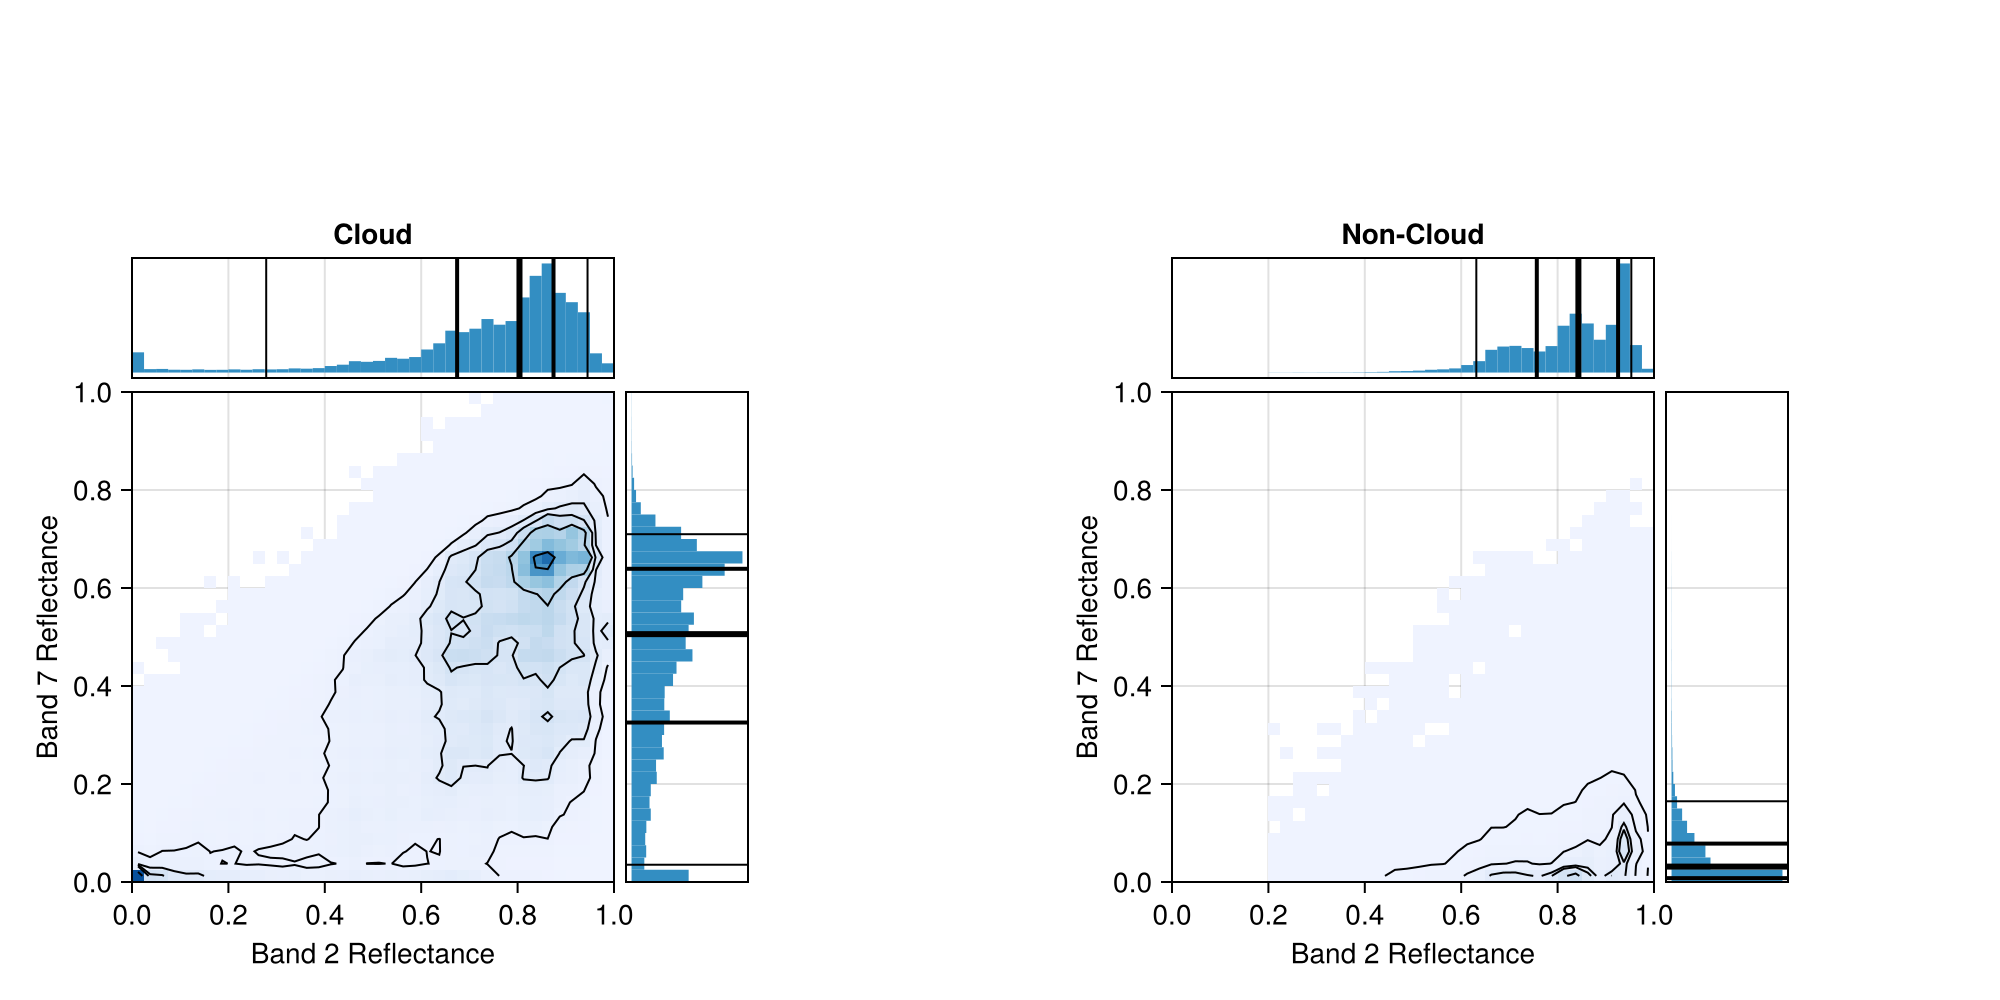

In [392]:
fig = Figure(size=(1000,500))

# Clouds on left
bins = 0:0.025:1
h2 = Hist1D(b2_clouds; binedges=bins);
h7 = Hist1D(b7_clouds, binedges=bins);
h2h7 = Hist2D((b2_clouds, b7_clouds), binedges=(bins, bins));

H = h2h7.bincounts
s = integral(h2h7)
Hd = H ./ s
F = range(0, maximum(Hd), 50)
L = round.([1-sum(Hd[Hd .> f]) for f in F], digits=3)

df = DataFrame(F=F, L=L)
df = df[.!nonunique(df, "L"), :];

pct = [0.05, 0.25, 0.5, 0.75, 0.95]
f = linear_interpolation(df[:, :L], df[:, :F])
levels = f.(pct) * s;

ax11, _ = hist(fig[1, 1],h2; axis=(xticks=0:0.2:1, yticks=[], title="Cloud"))
ax21, _h2h7 = plot(fig[2, 1], h2h7; colormap=:Blues_6, colorrange=(0, 2e5),
    axis=(ylabel="Band 7 Reflectance", xlabel="Band 2 Reflectance", 
        xticks=0:0.2:1, yticks=0:0.2:1))
contour!(ax21, h2h7; 
    levels=levels, labels=false, color=:black)
ax22, _ = hist(fig[2, 2], h7; direction=:x, axis=(yticks=0:0.2:1, xticks=[]))

b2_qs = quantile(b2_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
println("B2 quantiles", b2_qs)
vlines!(ax11, b2_qs, color=:black, linewidth=1)
vlines!(ax11, b2_qs[[2, 4]], color=:black, linewidth=2)
vlines!(ax11, b2_qs[[3]], color=:black, linewidth=3)

b7_qs = quantile(b7_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
hlines!(ax22, b7_qs, color=:black, linewidth=1)
hlines!(ax22, b7_qs[[2, 4]], color=:black, linewidth=2)
hlines!(ax22, b7_qs[[3]], color=:black, linewidth=3)

linkyaxes!(ax21, ax22)
linkxaxes!(ax11, ax21)


hidedecorations!(ax11, grid = false)
hidedecorations!(ax22, grid = false)

# RHS
idx = b2_non_clouds .> 0.2
h2 = Hist1D(b2_non_clouds[idx]; binedges=bins);
h7 = Hist1D(b7_non_clouds[idx], binedges=bins);
h2h7 = Hist2D((b2_non_clouds[idx], b7_non_clouds[idx]), binedges=(bins, bins));

H = h2h7.bincounts
s = integral(h2h7)
Hd = H ./ s
F = range(0, maximum(Hd), 50)
L = round.([1-sum(Hd[Hd .> f]) for f in F], digits=3)

df = DataFrame(F=F, L=L)
df = df[.!nonunique(df, "L"), :];

pct = [0.05, 0.25, 0.5, 0.75, 0.95]
f = linear_interpolation(df[:, :L], df[:, :F])
levels = f.(pct) * s;

ax14, _ = hist(fig[1, 4],h2; axis=(xticks=0:0.2:1, yticks=[], title="Non-Cloud"))
ax25, _ = hist(fig[2, 5], h7; direction=:x, axis=(yticks=0:0.2:1, xticks=[]))
ax24, _h2h7 = plot(fig[2, 4], h2h7; colormap=:Blues_6, colorrange=(0, 2e5),
    axis=(ylabel="Band 7 Reflectance", xlabel="Band 2 Reflectance", 
        xticks=0:0.2:1, yticks=0:0.2:1))
contour!(ax24, h2h7; 
    levels=levels, labels=false, color=:black)

ax22.aspect = 0.25
ax11.aspect = 4
# ax21.aspect=1
# ax24.aspect = 1
ax14.aspect = 4
ax25.aspect = 0.25

b2_qs = quantile(b2_non_clouds[idx], [0.05, 0.25, 0.5, 0.75, 0.95])
vlines!(ax14, b2_qs, color=:black, linewidth=1)
vlines!(ax14, b2_qs[[2, 4]], color=:black, linewidth=2)
vlines!(ax14, b2_qs[[3]], color=:black, linewidth=3)

b7_qs = quantile(b7_non_clouds[idx], [0.05, 0.25, 0.5, 0.75, 0.95])
hlines!(ax25, b7_qs, color=:black, linewidth=1)
hlines!(ax25, b7_qs[[2, 4]], color=:black, linewidth=2)
hlines!(ax25, b7_qs[[3]], color=:black, linewidth=3)

linkyaxes!(ax24, ax25)
linkxaxes!(ax14, ax24)
linkyaxes!(ax21, ax24)
hidedecorations!(ax25, grid = false)
hidedecorations!(ax14, grid = false)

colgap!(fig.layout, -85)
rowgap!(fig.layout,  -85)

ax22.titlegap=0

current_figure()

In [397]:
# Check color ranges
# Get numbers for band 2, band 7, band 1 histograms

B2 quantiles[0.2784313725490196, 0.6745098039215687, 0.803921568627451, 0.8745098039215686, 0.9450980392156862]
B7 quantiles[0.03529411764705882, 0.3254901960784314, 0.5058823529411764, 0.6392156862745098, 0.7098039215686275]
B2 quantiles[0.2784313725490196, 0.6745098039215687, 0.803921568627451, 0.8745098039215686, 0.9450980392156862]
B7 quantiles[0.03529411764705882, 0.3254901960784314, 0.5058823529411764, 0.6392156862745098, 0.7098039215686275]


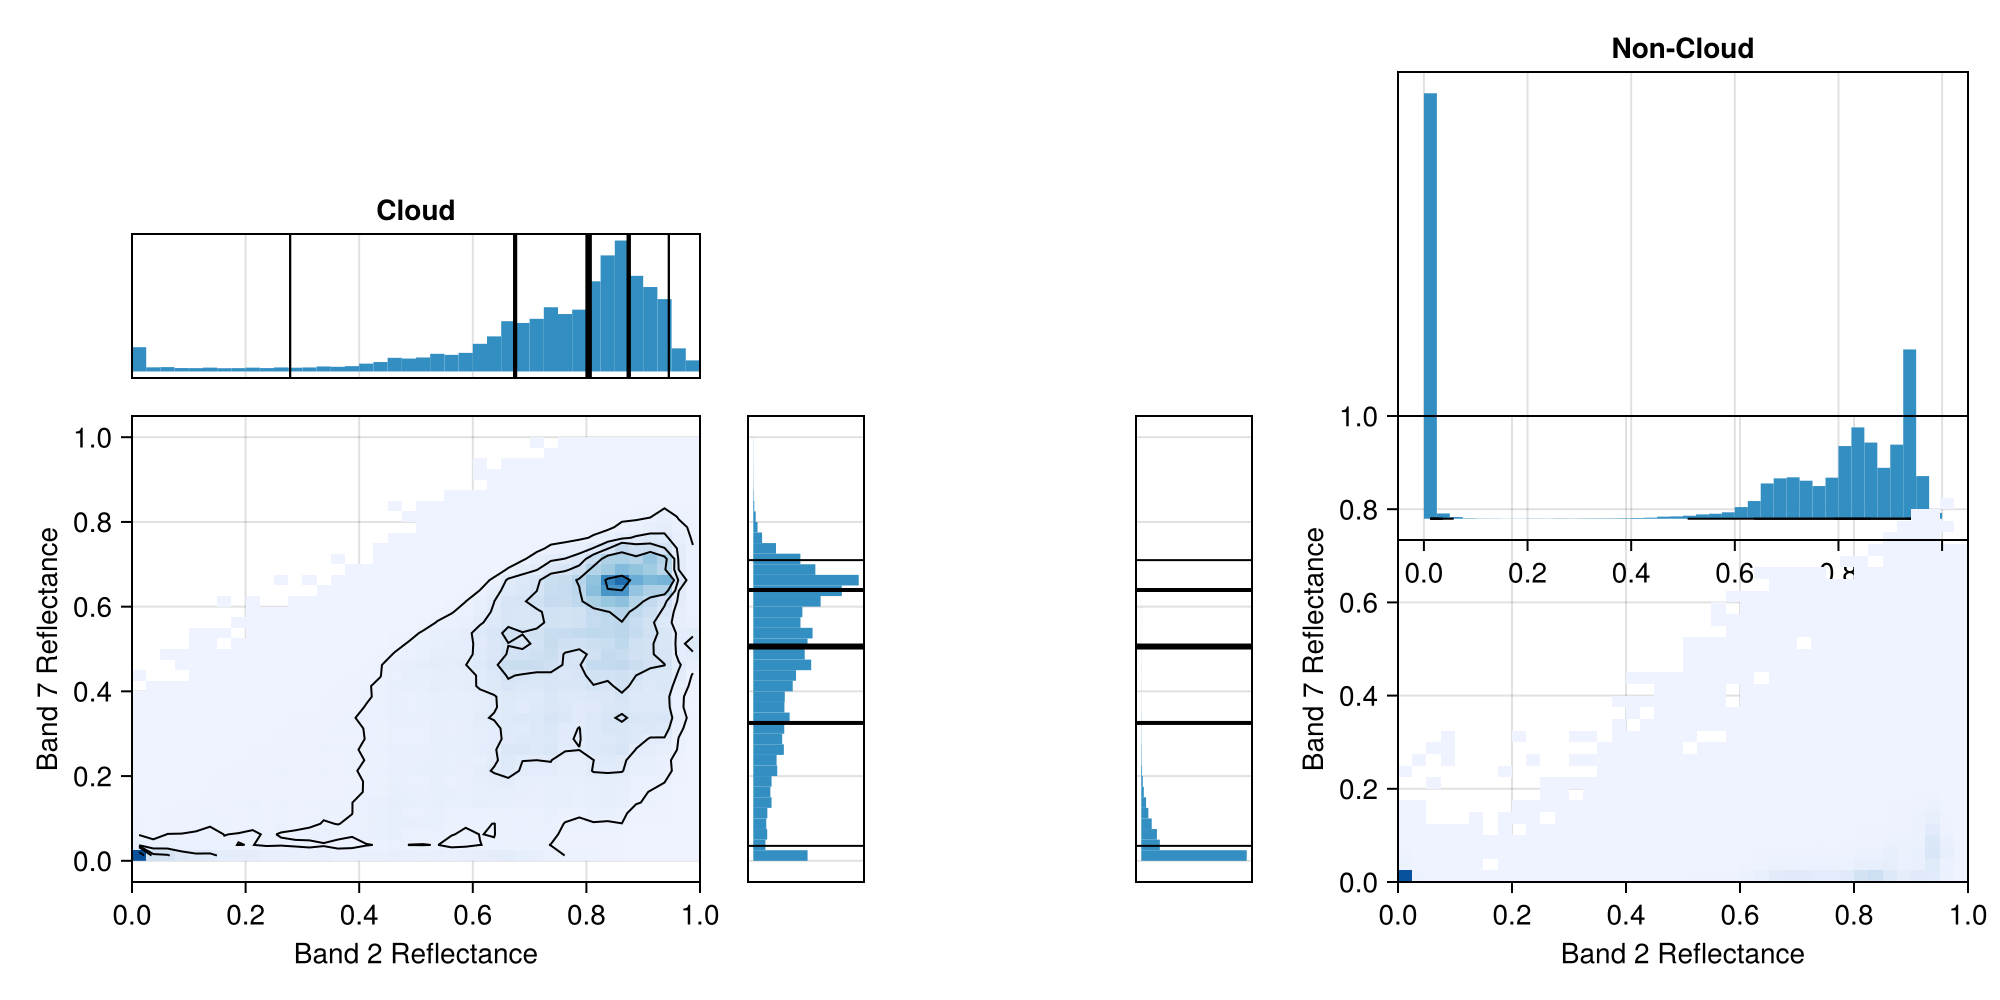

In [342]:
# statbox!(fig, h2h7; position=(2,4))
# save("../figures/fig_04a_cloud_histogram.pdf", fig)
# save("../figures/fig_04a_cloud_histogram.pdf", fig, px_per_unit=1)

# Non-clouds on right
bins = 0:0.025:1
h2 = Hist1D(b2_non_clouds; binedges=bins);
h7 = Hist1D(b7_non_clouds, binedges=bins);
h2h7 = Hist2D((b2_non_clouds, b7_non_clouds), binedges=(bins, bins));

H = h2h7.bincounts
s = integral(h2h7)
Hd = H ./ s
F = range(0, maximum(Hd), 50)
L = round.([1-sum(Hd[Hd .> f]) for f in F], digits=3)

df = DataFrame(F=F, L=L)
df = df[.!nonunique(df, "L"), :];

pct = [0.05, 0.25, 0.5, 0.75, 0.95]
f = linear_interpolation(df[:, :L], df[:, :F])
levels = f.(pct) * s;

ax4, _ = hist(fig[1, 4],h2; axis=(xticks=0:0.2:1, yticks=[], title="Non-Cloud"))
ax5, _h2h7 = plot(fig[2, 4], h2h7; colormap=:Blues_6, colorrange=(0, 2e5),
    axis=(ylabel="Band 7 Reflectance", xlabel="Band 2 Reflectance", 
        xticks=0:0.2:1, yticks=0:0.2:1))
contour!(ax4, h2h7; 
    levels=levels, labels=false, color=:black)
# Colorbar(fig[2, 5], _h2h7; label="Counts", labelrotation=-pi/2)
ax2, _ = hist(fig[2, 3], h7; direction=:x, axis=(yticks=0:0.2:1, xticks=[]))
ax2.aspect = 0.25
ax1.aspect = 4
b2_qs = quantile(b2_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
println("B2 quantiles", b2_qs)
vlines!(ax1, b2_qs, color=:black, linewidth=1)
vlines!(ax1, b2_qs[[2, 4]], color=:black, linewidth=2)
vlines!(ax1, b2_qs[[3]], color=:black, linewidth=3)


b7_qs = quantile(b7_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
println("B7 quantiles", b7_qs)
hlines!(ax2, b7_qs, color=:black, linewidth=1)
hlines!(ax2, b7_qs[[2, 4]], color=:black, linewidth=2)
hlines!(ax2, b7_qs[[3]], color=:black, linewidth=3)


linkyaxes!(ax3, ax2)
linkxaxes!(ax3, ax1)
hidedecorations!(ax1, grid = false)
hidedecorations!(ax2, grid = false)
colgap!(fig.layout, -90)
rowgap!(fig.layout,  -85)

fig

In [347]:
# print("B1 clouds", round.(quantile(b1_clouds, [0.05, 0.25, 0.5, 0.75, 0.95]), digits=2))
println("B2 clouds", round.(quantile(b2_clouds, [0.05, 0.25, 0.5, 0.75, 0.95]), digits=2))
println("B7 clouds", round.(quantile(b7_clouds, [0.05, 0.25, 0.5, 0.75, 0.95]), digits=2))



B2 clouds[0.28, 0.67, 0.8, 0.87, 0.95]
B7 clouds[0.04, 0.33, 0.51, 0.64, 0.71]


In [349]:
b2_clouds

11273781-element Vector{Float64}:
 0.5529411764705883
 0.5882352941176471
 0.6470588235294118
 0.6666666666666666
 0.6235294117647059
 0.6
 0.615686274509804
 0.6313725490196078
 0.5450980392156862
 0.5568627450980392
 0.5254901960784314
 0.49019607843137253
 0.4980392156862745
 ⋮
 0.8235294117647058
 0.8431372549019608
 0.8470588235294118
 0.8352941176470589
 0.8588235294117647
 0.8627450980392157
 0.8588235294117647
 0.8627450980392157
 0.8705882352941177
 0.8666666666666667
 0.8588235294117647
 0.8509803921568627